In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import root_mean_squared_error

from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel
from darts.explainability import TFTExplainer
from darts.dataprocessing.transformers import StaticCovariatesTransformer

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


### Download do M5 Forecasting Dataset (se já não baixado!):

In [ ]:
DATA_DIR = r"../Data"
COMPETITION = "m5-forecasting-accuracy"

os.makedirs(DATA_DIR, exist_ok=True)

api = KaggleApi()
api.authenticate()

api.competition_download_files(
    COMPETITION,
    path=DATA_DIR,
    quiet=False
    )

zip_path = os.path.join(DATA_DIR, f"{COMPETITION}.zip")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

os.remove(zip_path)

### Importação do dataset:

**Sumário**:

1. ```sales_train_validation (train_df)```: Representa a demanda de cada produto ao longo dos 1913 dias de análise. Serve como um conjunto de treinamento. É o material que passará pelo **Cross-Validation**.
2. ```sales_train_evaluation (eval_df)```: Representa a demanda de cada produto ao longo dos 1941 dias de análise. Serve como um conjunto de validação para o treinamento do modelo.
3. ```calendar```: Representa o calendário por trás da janela temporal de análise. É o que ajudará a incluir a operação sazonal em cima dos produtos. Permite a relação entre cada dataset.
4. ```sell_prices```: Representa o valor de cada produto para cada semana (o código da semana é representado por "wm_yr_wk").

Um modelo de TFT infelizmente foi impossível de ser feito diante do Dataset completo, visto que ele é tão grande que é muito fácil acontecer problemas gravíssimos de alocação de memória. A minha máquina tem 16 GB de RAM e infelizmente apanhou e feio no pré-processamento, tanto que foram poucas as vezes que um resultado concreto foi produzido.

A decisão aqui foi entregar os dados mais atuais ao modelo. Dados muito antigos, principalmente considerando a natureza do problema, geralmente tendem a não entregar tanta relevância. Nisso, **o modelo será baseado em uma subamostragem do M5 Forecasting**, datado do período de um ano.

In [ ]:
train_df = pd.read_csv(r'../Data/sales_train_validation.csv').drop(columns='id')
eval_df = pd.read_csv(r'../Data/sales_train_evaluation.csv').drop(columns='id')
calendar = pd.read_csv(r'../Data/calendar.csv').drop(columns=['weekday', 'wday', 'month', 'year'])
sell_prices = pd.read_csv(r'../Data/sell_prices.csv')


In [ ]:
cols_to_drop = [f'd_{i}' for i in range(1, 1434)]

train_df.drop(columns=cols_to_drop, inplace=True)
eval_df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
cutoff_date = '2015-01-01' #  Representa o d_1434
cutoff_wm_yr_wk = 11448

In [ ]:
calendar['date'] = pd.to_datetime(calendar['date'])

calendar = calendar[calendar['date'] >= cutoff_date]
calendar.reset_index(drop=True, inplace=True)

In [ ]:
sell_prices = sell_prices[sell_prices['wm_yr_wk'] >= cutoff_wm_yr_wk]
sell_prices.reset_index(drop=True, inplace=True)

### Análise dos DataFrames:

In [ ]:
train_df

,item_id,dept_id,cat_id,store_id,state_id,d_1434,d_1435,d_1436,d_1437,d_1438,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,1,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2,4,3,3,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,3,0,1,1,1,...,2,1,1,0,1,1,2,2,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,0,0,1,...,2,0,0,0,0,0,1,0,0,1
30486,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
30487,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,1,2,0,3,1,...,2,1,0,2,0,1,0,0,1,0
30488,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,0,...,0,0,1,0,0,1,0,3,1,3


In [ ]:
eval_df

,item_id,dept_id,cat_id,store_id,state_id,d_1434,d_1435,d_1436,d_1437,d_1438,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,1,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2,4,3,3,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,3,0,1,1,1,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,0,0,1,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,1,2,0,3,1,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [ ]:
calendar

,date,wm_yr_wk,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2015-01-01,11448,d_1434,NewYear,National,NaN,NaN,1,1,0
1,2015-01-02,11448,d_1435,NaN,NaN,NaN,NaN,1,0,1
2,2015-01-03,11449,d_1436,NaN,NaN,NaN,NaN,1,1,1
3,2015-01-04,11449,d_1437,NaN,NaN,NaN,NaN,1,0,0
4,2015-01-05,11449,d_1438,NaN,NaN,NaN,NaN,1,1,1
...,...,...,...,...,...,...,...,...,...,...
531,2016-06-15,11620,d_1965,NaN,NaN,NaN,NaN,0,1,1
532,2016-06-16,11620,d_1966,NaN,NaN,NaN,NaN,0,0,0
533,2016-06-17,11620,d_1967,NaN,NaN,NaN,NaN,0,0,0
534,2016-06-18,11621,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [ ]:
sell_prices #  Preços variam semanalmente.

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11448,8.26
1,CA_1,HOBBIES_1_001,11449,8.26
2,CA_1,HOBBIES_1_001,11450,8.26
3,CA_1,HOBBIES_1_001,11451,8.26
4,CA_1,HOBBIES_1_001,11452,8.26
...,...,...,...,...
2363362,WI_3,FOODS_3_827,11617,1.00
2363363,WI_3,FOODS_3_827,11618,1.00
2363364,WI_3,FOODS_3_827,11619,1.00
2363365,WI_3,FOODS_3_827,11620,1.00


In [ ]:
train_df.isna().sum()

item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
           ..
d_1909      0
d_1910      0
d_1911      0
d_1912      0
d_1913      0
Length: 485, dtype: int64

In [ ]:
eval_df.isna().sum()

item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 513, dtype: int64

In [ ]:
calendar.isna().sum()

date              0
wm_yr_wk          0
d                 0
event_name_1    487
event_type_1    487
event_name_2    535
event_type_2    535
snap_CA           0
snap_TX           0
snap_WI           0
dtype: int64

In [ ]:
sell_prices.isna().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

### Pré-processamento:

In [ ]:
for col in ['event_name_1','event_type_1','event_name_2','event_type_2']:
    calendar[col] = calendar[col].fillna('NO_EVENT')
    calendar[col] = calendar[col].astype('category').cat.codes

calendar['date'] = pd.to_datetime(calendar['date'], format='%Y-%m-%d')
calendar

,date,wm_yr_wk,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2015-01-01,11448,d_1434,19,2,1,1,1,1,0
1,2015-01-02,11448,d_1435,18,1,1,1,1,0,1
2,2015-01-03,11449,d_1436,18,1,1,1,1,1,1
3,2015-01-04,11449,d_1437,18,1,1,1,1,0,0
4,2015-01-05,11449,d_1438,18,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
531,2016-06-15,11620,d_1965,18,1,1,1,0,1,1
532,2016-06-16,11620,d_1966,18,1,1,1,0,0,0
533,2016-06-17,11620,d_1967,18,1,1,1,0,0,0
534,2016-06-18,11621,d_1968,18,1,1,1,0,0,0


In [ ]:
train_df = train_df.melt(id_vars=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name='day')
eval_df = eval_df.melt(id_vars=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name='day')

In [ ]:
train_df = train_df.rename(columns={'value': 'y', 'day': 'd'})
eval_df = eval_df.rename(columns={'value': 'y', 'day': 'd'})

In [ ]:
wideSalesCalendar = train_df.merge(calendar,
                                   on='d',
                                   how='left').drop(columns='d')

demandComplete_train = wideSalesCalendar.merge(sell_prices,
                                               left_on=['item_id','store_id','wm_yr_wk'],
                                               right_on=['item_id','store_id','wm_yr_wk'],
                                               how='left')

wideSalesCalendar = eval_df.merge(calendar,
                                   on='d',
                                   how='left').drop(columns='d')

demandComplete_eval = wideSalesCalendar.merge(sell_prices,
                                               left_on=['item_id','store_id','wm_yr_wk'],
                                               right_on=['item_id','store_id','wm_yr_wk'],
                                               how='left')

In [ ]:
train_df

,item_id,dept_id,cat_id,store_id,state_id,d,y
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1434,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1434,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1434,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1434,2
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1434,3
...,...,...,...,...,...,...,...
14635195,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1913,1
14635196,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1913,0
14635197,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1913,0
14635198,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1913,3


#### Análise dos DataFrames:

In [ ]:
demandComplete_train

,item_id,dept_id,cat_id,store_id,state_id,y,date,wm_yr_wk,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,8.26
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,3.97
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,2.97
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2,2015-01-01,11448,19,2,1,1,1,1,0,4.64
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,3,2015-01-01,11448,19,2,1,1,1,1,0,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635195,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,1,2016-04-24,11613,18,1,1,1,0,0,0,2.98
14635196,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,2016-04-24,11613,18,1,1,1,0,0,0,2.48
14635197,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,2016-04-24,11613,18,1,1,1,0,0,0,3.98
14635198,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,3,2016-04-24,11613,18,1,1,1,0,0,0,1.28


In [ ]:
demandComplete_eval

,item_id,dept_id,cat_id,store_id,state_id,y,date,wm_yr_wk,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,8.26
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,3.97
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,2015-01-01,11448,19,2,1,1,1,1,0,2.97
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2,2015-01-01,11448,19,2,1,1,1,1,0,4.64
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,3,2015-01-01,11448,19,2,1,1,1,1,0,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15488915,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,1,2016-05-22,11617,18,1,1,1,0,0,0,2.98
15488916,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,2016-05-22,11617,18,1,1,1,0,0,0,2.48
15488917,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,2,2016-05-22,11617,18,1,1,1,0,0,0,3.98
15488918,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,2016-05-22,11617,18,1,1,1,0,0,0,1.28


### Encoders (para LSTM Encoders):

In [ ]:
def encode_year(idx):
    return (idx.year - 1950) / 50

add_encoders = {
    'cyclic': {'future': ['day', 'dayofweek', 'month']},
    'datetime_attribute': {'future': ['day', 'dayofweek', 'month', 'week']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
}

### Instância do "Time Series format" dos DataFrames

In [ ]:
time_column = 'date'
target = 'y'
group_col = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
freq = 'd'

In [ ]:
series = TimeSeries.from_group_dataframe(df=demandComplete_train,
                                   time_col=time_column,
                                   group_cols=group_col,
                                   value_cols=target,
                                   freq=freq)

In [ ]:
series[0]

,y
date,
2015-01-01,1.0
2015-01-02,0.0
2015-01-03,1.0
2015-01-04,0.0
2015-01-05,1.0
...,...
2016-04-20,1.0
2016-04-21,0.0
2016-04-22,1.0


## Covariáveis Passadas e Futuras:

In [ ]:
COVARIATES = ['sell_price', 'snap_CA', 'snap_TX', 'snap_WI', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
past_covariates = TimeSeries.from_group_dataframe(df = demandComplete_train,
                                                  time_col=time_column,
                                                  group_cols=group_col,
                                                  value_cols=COVARIATES,
                                                  freq=freq)

In [ ]:
future_covariates = TimeSeries.from_group_dataframe(df = demandComplete_eval,
                                                  time_col=time_column,
                                                  group_cols=group_col,
                                                  value_cols=COVARIATES,
                                                  freq=freq)

In [ ]:
calendar['snap_CA'].value_counts()

snap_CA
0    356
1    180
Name: count, dtype: int64

In [ ]:
categorical = [
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
    "snap_CA",
    "snap_TX",
    "snap_WI"
]


num_past_covariates = [
    ts[[c for c in ts.components if c not in categorical]]
    for ts in past_covariates
]


num_future_covariates = [
    ts[[c for c in ts.components if c not in categorical]]
    for ts in future_covariates
]

In [ ]:
scaler1 = Scaler()
staticTransformer = StaticCovariatesTransformer()


y_scaled = scaler1.fit_transform(series[:40])
y_encoded = staticTransformer.fit_transform(y_scaled)

In [ ]:
len(y_encoded)

40

## TFT Model:

In [ ]:
forecast_horizon = 28 #  Mesma janela definido pelo M5 Forecasting: 28 dias.

In [ ]:
model = TFTModel(input_chunk_length=112, output_chunk_length=forecast_horizon,
                 hidden_size=8, lstm_layers=2, num_attention_heads=4,
                 dropout=0.1, n_epochs=7, use_static_covariates=True,
                 pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
                 random_state=42, add_encoders=add_encoders)

In [ ]:
model.fit(y_encoded[:40], past_covariates=past_covariates,
          future_covariates=future_covariates,
          max_samples_per_ts=240, verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=7` reached.


TFTModel(output_chunk_shift=0, hidden_size=8, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=112, output_chunk_length=28, n_epochs=7, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, random_state=42, add_encoders={'cyclic': {'future': ['day', 'dayofweek', 'month']}, 'datetime_attribute': {'future': ['day', 'dayofweek', 'month', 'week']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x00000212EDF1D480>], 'future': [<function encode_year at 0x00000212EDF1D480>]}, 'transformer': Scaler, 'tz': 'CET'})

In [ ]:
cv = model.historical_forecasts(
    series = y_encoded[:40],
    past_covariates=past_covariates,
    future_covariates=future_covariates,
    forecast_horizon=forecast_horizon,
    start = len(y_encoded[0]) - 5 * forecast_horizon,
    retrain=True,
    last_points_only=False,
    stride=forecast_horizon
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.9 K  | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 12.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 8.3 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 304    | train
7  | static_cont

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=7` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.9 K  | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 12.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 8.3 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 304    | train
7  | static_cont

...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 1.9 K  | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 12.8 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 8.3 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 304    | train
7  | static_cont

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=7` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
rmse_list = []
mape_list = []
for i in range(len(cv[0])):
    period_predictions = [cv[j][i] for j in range(len(cv))]

    period_predictions_unscaled = scaler1.inverse_transform(period_predictions)

    for j, prediction_ts in enumerate(period_predictions_unscaled):
        original_ts = series[j]

        static_covs = original_ts.static_covariates

        item_id = static_covs['item_id'].item()
        store_id = static_covs['store_id'].item()

        start_date = prediction_ts.start_time()
        end_date = prediction_ts.end_time()

        mask = (
            (demandComplete_train['item_id'] == item_id) &
            (demandComplete_train['store_id'] == store_id) &
            (demandComplete_train['date'] >= start_date) &
            (demandComplete_train['date'] <= end_date)
        )

        actuals_df = demandComplete_train[mask].sort_values('date')

        y_true = actuals_df['y'].values
        y_pred = prediction_ts.values().flatten()

        if len(y_true) == len(y_pred):
            rmse = root_mean_squared_error(y_true, y_pred)
            mape = np
            rmse_list.append(rmse)
        else:
            print(f"Erro de alinhamento para {item_id} na loja {store_id}")
            print(f"Previsto: {len(y_pred)} dias, Real: {len(y_true)} dias")

print(f'The Mean RMSE is: {np.mean(rmse_list)}')

The Mean RMSE is: 2.887351442234689


Only 5 TimeSeries (lists) were provided which is lower than the number of series (n=40) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


Plotando validação para: Item FOODS_1_003 na Loja WI_1


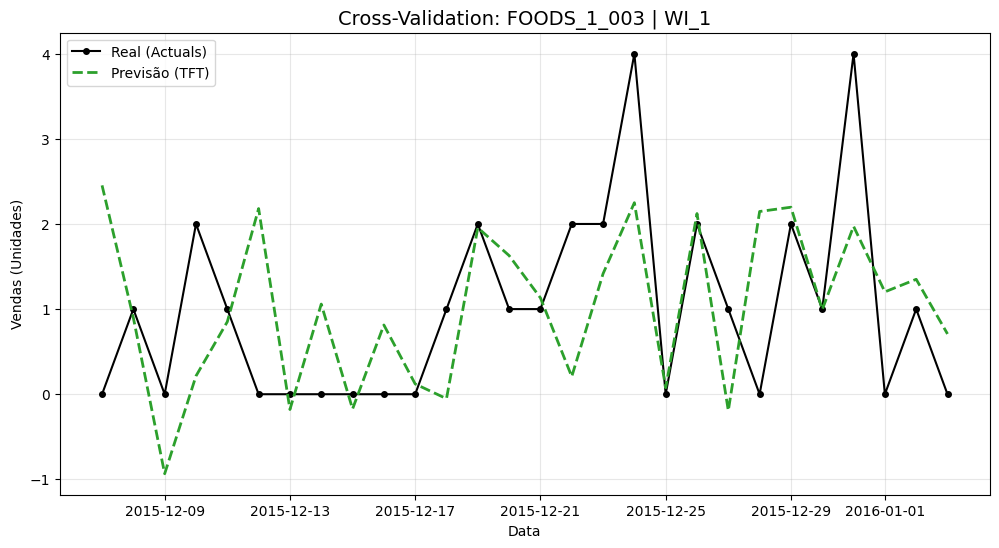

In [ ]:
indice_produto = 27 #  Índice variado de 0 a 39, para plotar o CV de um produto em uma loja

ts_original = series[indice_produto]
metadados = ts_original.static_covariates

item_id = metadados['item_id'].item()
store_id = metadados['store_id'].item()

predictions_scaled = cv[indice_produto]

period_predictions_unscaled = scaler1.inverse_transform(predictions_scaled)

if isinstance(period_predictions_unscaled, list):
    prediction_ts = period_predictions_unscaled[0]
else:
    prediction_ts = period_predictions_unscaled

prediction_pd = prediction_ts.to_series()

start_date = prediction_pd.index.min()
end_date = prediction_pd.index.max()

mask = (
    (demandComplete_train['item_id'] == item_id) &
    (demandComplete_train['store_id'] == store_id) &
    (demandComplete_train['date'] >= start_date) &
    (demandComplete_train['date'] <= end_date)
)

actuals_df = demandComplete_train[mask].sort_values('date').set_index('date')
actuals_pd = actuals_df['y']

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(actuals_pd.index, actuals_pd.values, label='Real (Actuals)', color='black', marker='o', markersize=4)
ax.plot(prediction_pd.index, prediction_pd.values, label='Previsão (TFT)', color='#2ca02c', linewidth=2, linestyle='--')

ax.set_title(f'Cross-Validation: {item_id} | {store_id}', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Vendas (Unidades)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
explainer = TFTExplainer(
    model=model,
    background_series=y_encoded[:32],
    background_past_covariates=past_covariates,
    background_future_covariates=future_covariates
)

explainability_result = explainer.explain()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

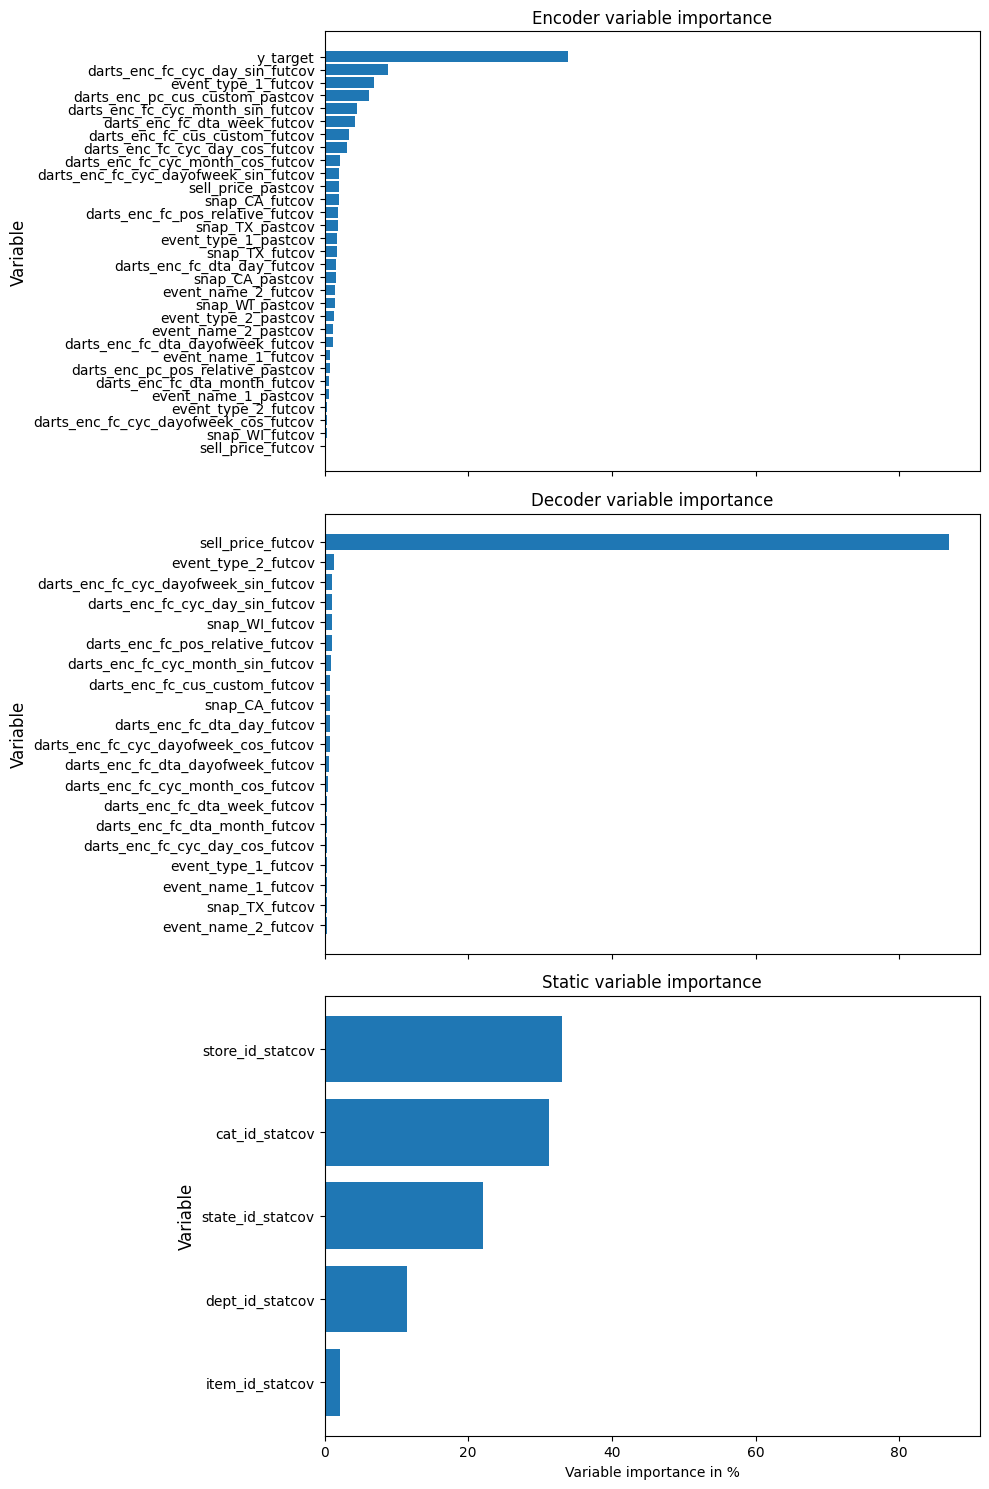

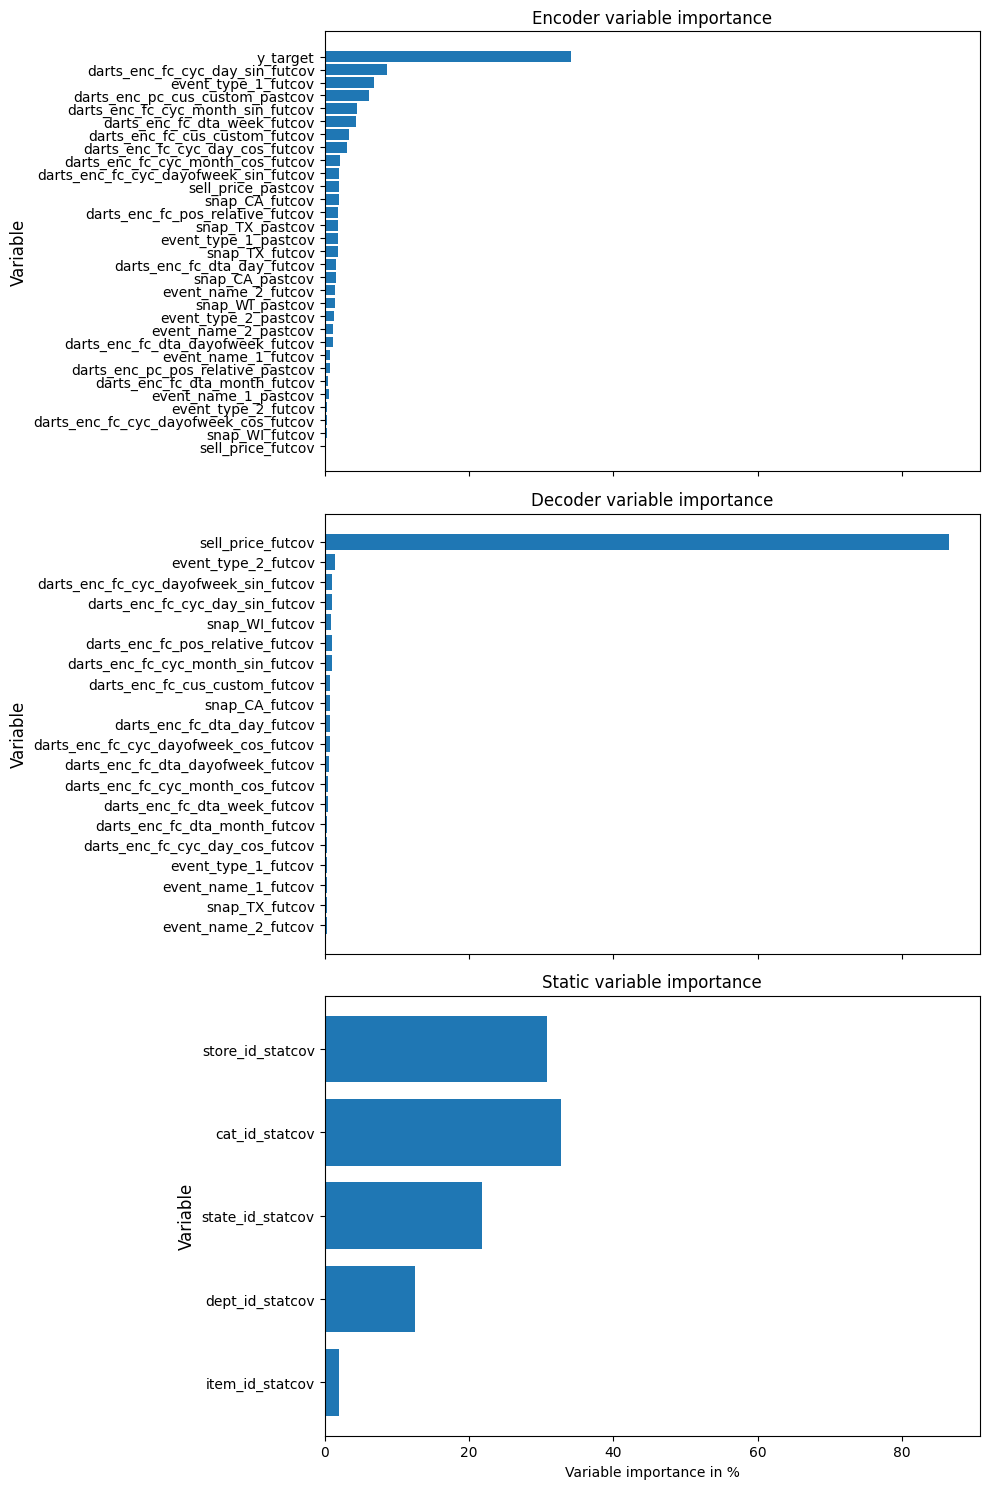

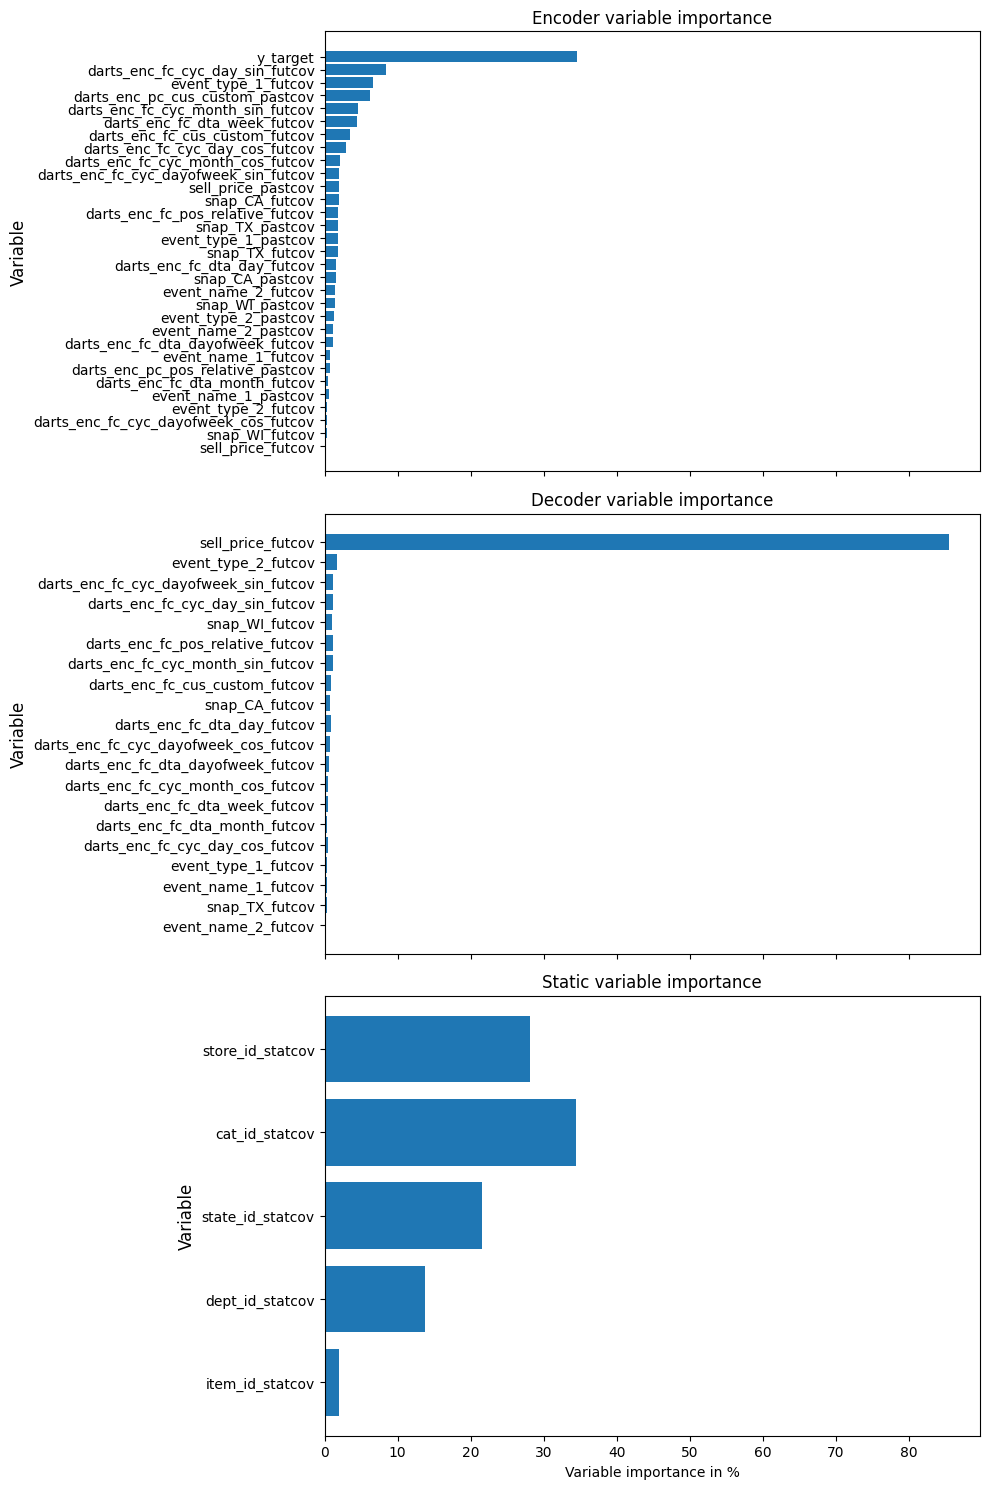

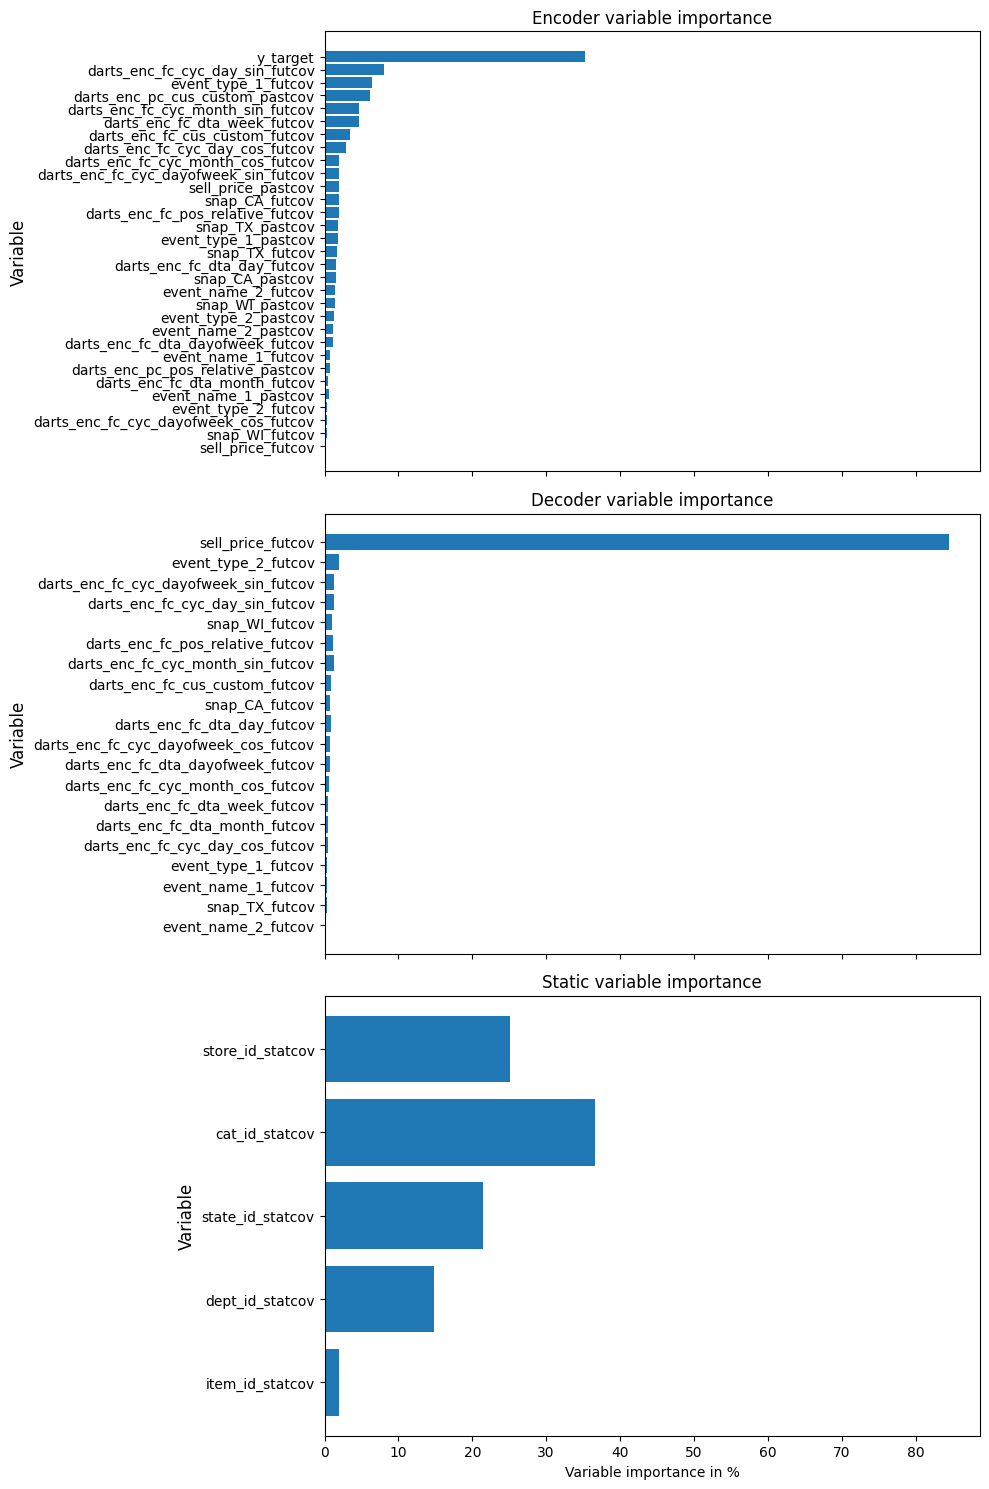

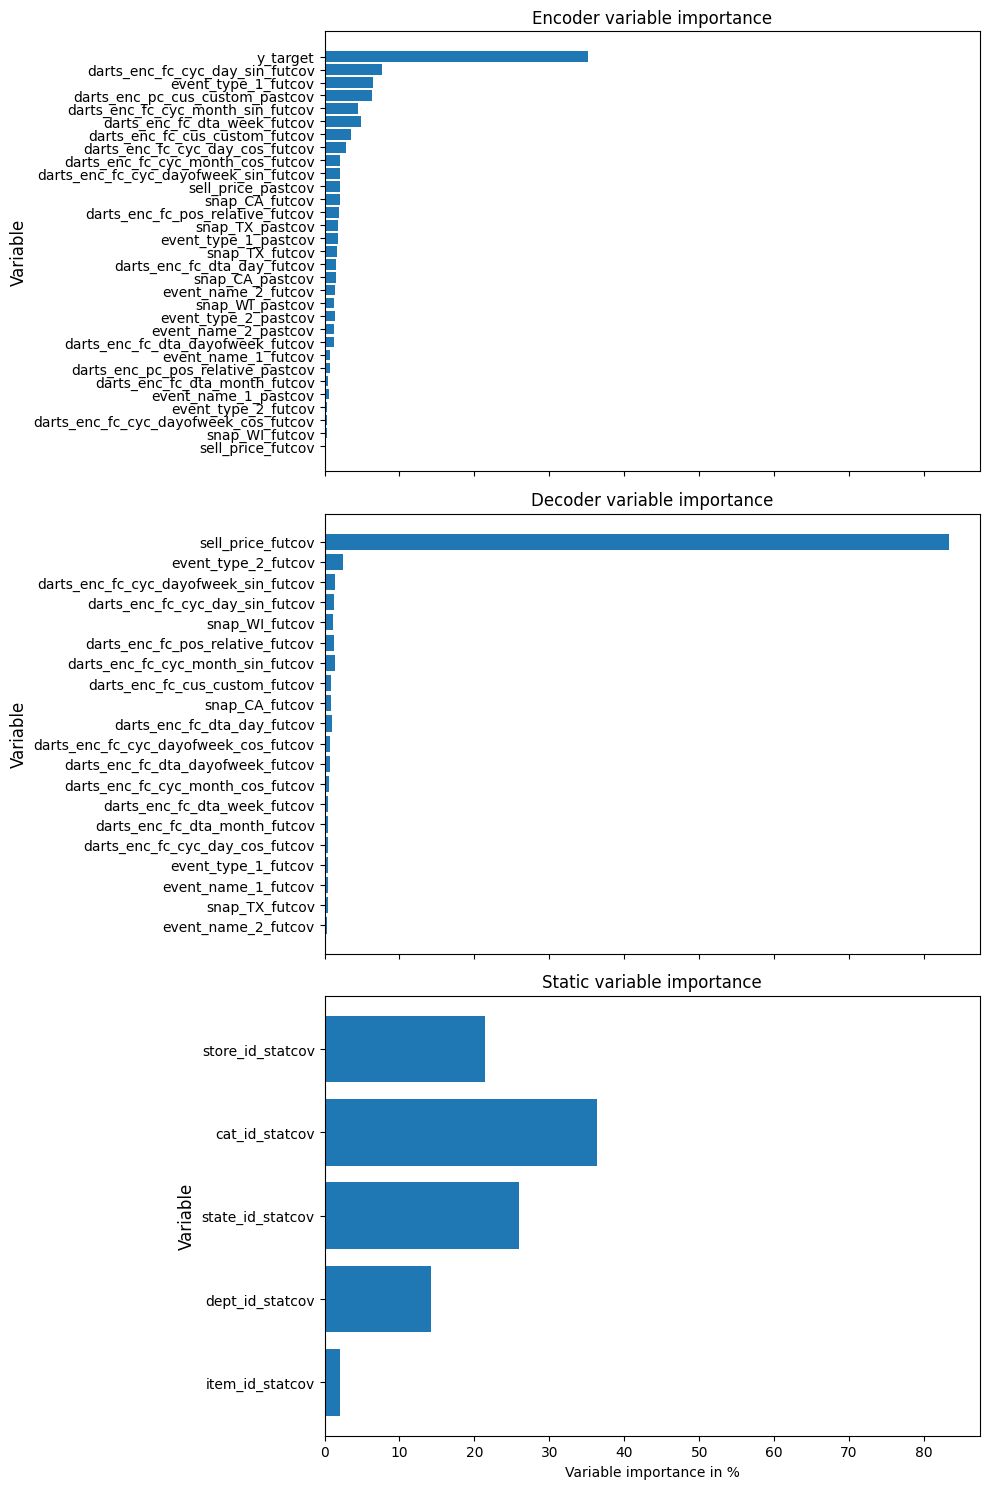

In [ ]:
explainer.plot_variable_selection(explainability_result, fig_size=(10, 15))

In [ ]:
explainer.plot_attention(explainability_result, plot_type='time')